# 12. Coupled thermal-orbital evolution

The earlier notebooks each gave an instantaneous rate: a tidal heating, a `da/dt`, a `de/dt`. Real
evolution couples them. Tidal heating warms the interior, a warmer interior deforms differently and so
dissipates differently, and the changing dissipation feeds back on the orbit. Following that loop means
integrating a small system of ordinary differential equations in time.

This capstone builds that loop for a moon and integrates it over a billion years with CyRK. The state is
the semi-major axis, the eccentricity, and the mantle temperature (the spin stays synchronous). The
expensive piece, the rheology's frequency- and temperature-dependent Love number, is computed once with
the radial solver and tabulated; the ODE right-hand side then interpolates it, so the integration is fast.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import CyRK

from TidalPy.constants import G
from TidalPy.RadialSolver_x import radial_solver
from TidalPy.rheology_x import Maxwell
from TidalPy.viscosity_x import make_viscosity

# A homogeneous rocky moon raised by a giant-planet host.
R = 1.8216e6
M = 8.9319e22
RHO = M / (4.0 / 3.0 * np.pi * R**3)
M_HOST = 1.898e27
A0 = 4.217e8
N0 = np.sqrt(G * M_HOST / A0**3)
SHEAR = 60.0e9
YEAR = 3.15576e7


## Precomputing the Love-number response

The mantle's viscosity follows an Arrhenius law, so it drops sharply as the interior warms. Feeding that temperature-dependent viscosity through a Maxwell rheology and the radial solver gives the dissipation factor `-Im(k2)` as a function of temperature. We build it once on a temperature grid and interpolate during the integration.

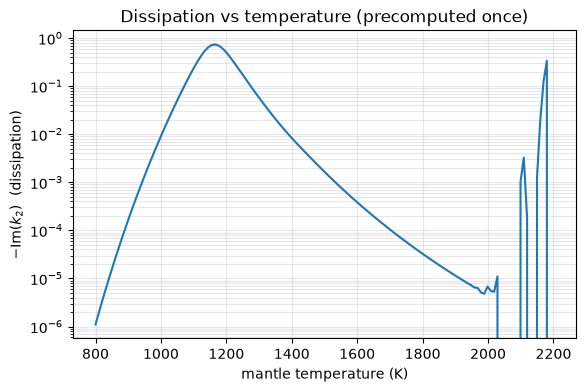

In [2]:
viscosity = make_viscosity("arrhenius",
    {"reference_viscosity": 1.0e16, "activation_energy": 3.0e5, "reference_temperature": 1500.0})

SLICES = 50
_radius = np.linspace(0.0, R, SLICES)
_density = np.full(SLICES, RHO)
_maxwell = Maxwell()

def neg_im_k2(temperature):
    eta = viscosity.calc_viscosity(temperature, 1.0e9)
    complex_shear = _maxwell.calc_complex_modulus(SHEAR, eta, N0)
    sol = radial_solver(_radius, _density, np.full(SLICES, 200.0e9 + 0j),
                        np.full(SLICES, complex_shear, dtype=np.complex128),
                        N0, RHO, ("solid",), (True,), (False,), np.array([R]),
                        degree_l=2, solve_for=("tidal",))
    return -complex(np.atleast_1d(sol.k)[0]).imag

temp_grid = np.linspace(800.0, 2200.0, 140)
imk_grid = np.array([neg_im_k2(T) for T in temp_grid])

def imk(T):
    return float(np.interp(min(max(T, temp_grid[0]), temp_grid[-1]), temp_grid, imk_grid))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(temp_grid, imk_grid)
ax.set_xlabel("mantle temperature (K)")
ax.set_ylabel(r"$-\mathrm{Im}(k_2)$  (dissipation)")
ax.set_title("Dissipation vs temperature (precomputed once)")
ax.grid(alpha=0.3, which="both")
plt.show()


## The coupled ODE

The leading-order secular equations for a synchronously rotating moon: tidal heating drives the interior temperature against a simple cooling law, and drains the orbit's energy so that the semi-major axis and eccentricity shrink. Everything hinges on the interpolated dissipation `-Im(k2)(T)`.

In [3]:
CP = 1200.0            # mantle heat capacity, J/kg/K
T_SURFACE = 110.0      # surface temperature the interior cools toward, K
COOLING = 1.8e11       # cooling coefficient, W/K

def tidal_heating(a, e, T):
    n = np.sqrt(G * M_HOST / a**3)
    return 10.5 * imk(T) * G * M_HOST**2 * R**5 * max(e, 0.0)**2 * n / a**6

def derivatives(t, y):
    a, e, T = y
    e = max(e, 0.0)
    T = min(max(T, T_SURFACE), 2200.0)
    heat = tidal_heating(a, e, T)
    da_dt = -2.0 * a**2 * heat / (G * M_HOST * M)              # orbital energy loss
    de_dt = da_dt * (1.0 - e**2) / (2.0 * a * max(e, 1.0e-4))  # angular momentum conservation
    dT_dt = (heat - COOLING * (T - T_SURFACE)) / (M * CP)      # heat balance
    return np.array([da_dt, de_dt, dT_dt])


## Integrating one billion years

CyRK integrates the system with an adaptive Runge-Kutta method. The evolution is fastest at the start, so we sample the output logarithmically in time to resolve it.

In [4]:
y0 = np.array([A0, 0.03, 1400.0])
t_end = 1.0e9 * YEAR
t_eval = np.concatenate([[0.0], np.logspace(np.log10(1.0e5 * YEAR), np.log10(t_end), 300)])

result = CyRK.pysolve_ivp(derivatives, (0.0, t_end), y0, method="RK23",
                          rtol=1.0e-6, atol=1.0e-9, t_eval=t_eval, max_step=1.0e6 * YEAR)
print("integration succeeded:", result.success)

t = np.asarray(result.t)
a, e, T = np.asarray(result.y)
heat = np.array([tidal_heating(a[i], e[i], T[i]) for i in range(t.size)])
spin = np.sqrt(G * M_HOST / a**3)     # synchronous: spin tracks the mean motion
t_myr = t / YEAR / 1.0e6


integration succeeded: True


The coupled history. Tidal dissipation circularizes the orbit within a few hundred million years; as the eccentricity falls, the heating collapses and the mantle cools to the surface temperature. The semi-major axis barely moves. This is why an isolated moon cannot stay tidally active: without something to keep pumping its eccentricity, like the orbital resonance that sustains the real Io, the heating fades away.

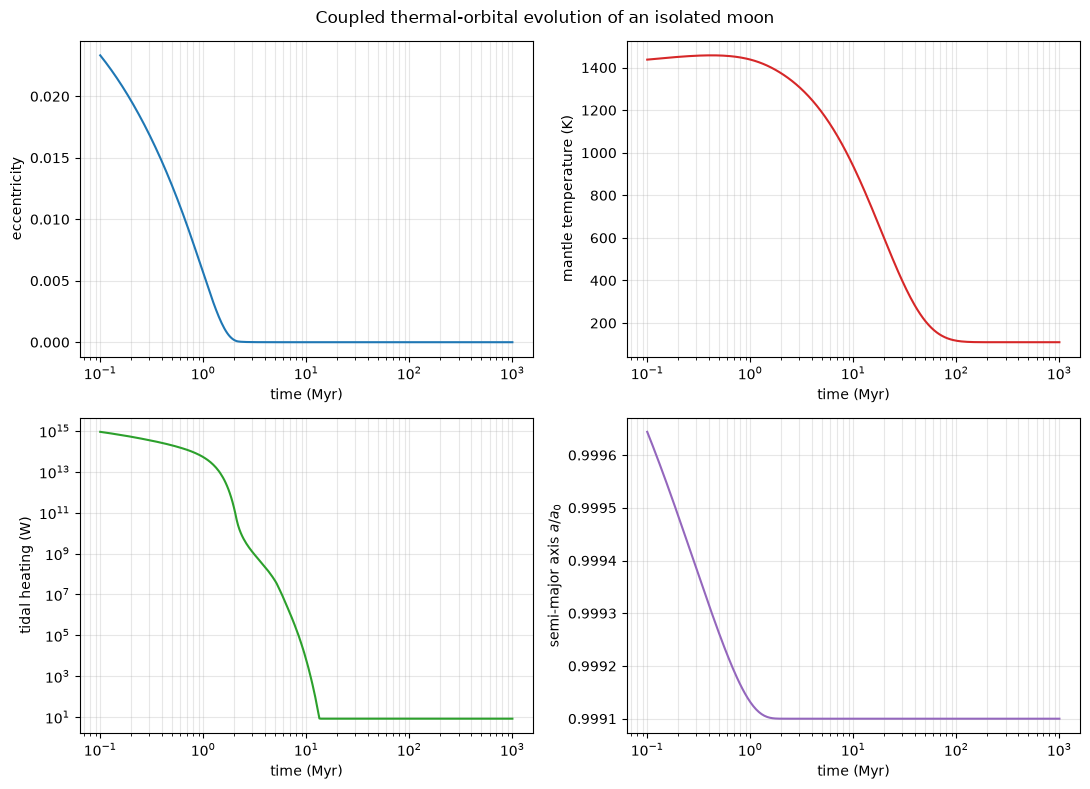

start : e=0.0300  T=1400 K  heating=2.78e+15 W
end   : e=1.422e-07  T=110 K  heating=8.30e+00 W


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
mask = t_myr > 0

axes[0, 0].plot(t_myr[mask], e[mask])
axes[0, 0].set_ylabel("eccentricity")

axes[0, 1].plot(t_myr[mask], T[mask], color="tab:red")
axes[0, 1].set_ylabel("mantle temperature (K)")

axes[1, 0].semilogy(t_myr[mask], heat[mask], color="tab:green")
axes[1, 0].set_ylabel("tidal heating (W)")

axes[1, 1].plot(t_myr[mask], a[mask] / A0, color="tab:purple")
axes[1, 1].set_ylabel(r"semi-major axis $a/a_0$")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.set_xlabel("time (Myr)")
    ax.grid(alpha=0.3, which="both")
fig.suptitle("Coupled thermal-orbital evolution of an isolated moon")
fig.tight_layout()
plt.show()

print(f"start : e={e[0]:.4f}  T={T[0]:.0f} K  heating={heat[0]:.2e} W")
print(f"end   : e={e[-1]:.4g}  T={T[-1]:.0f} K  heating={heat[-1]:.2e} W")


## Recap

- Coupling the pieces from the earlier notebooks, tidal heating, interior rheology, and orbital rates,
  gives a small ODE that CyRK integrates in time.
- Precomputing the rheology's `-Im(k2)(T)` with the radial solver keeps the right-hand side cheap, so a
  billion-year integration runs in a moment.
- Left alone, an eccentric moon rapidly circularizes and cools. Sustained tidal heating, as at Io,
  requires an external forcing such as an orbital resonance to keep the eccentricity pumped up.

This is the end of the demo track. The `Basics`, `Physics`, and `Systems` notebooks together cover
building worlds, computing their tides, and evolving whole systems with TidalPy's `_x` API.
